## 🏦 Loan Approval Analysis & Prediction

## 📖 Overview
This project aims to analyze the factors that influence loan approval decisions and assess credit risk.  
By exploring various attributes such as an applicant's age, income, employment experience, and credit history, we try to understand what contributes most to a loan being approved or rejected.

## 🎯 Objective
The main objective is to:
- Analyze the relationship between different financial and demographic features and loan approval.
- Identify key risk factors that indicate potential loan defaults.
- Build a machine learning classification model to predict loan status.

## 🎯 Target Variable
- **loan_status** → Represents the final decision on the loan (binary classification: 1 for Approved, 0 for Rejected/Default).

## 2. Dataset Description

The dataset contains multiple features related to applicants' personal background, financial standing, and specific loan details.  

**Data Dictionary:**
- **person_age**: Applicant's age in years.
- **person_gender**: Applicant's gender.
- **person_education**: Highest level of education attained.
- **person_income**: Annual income of the applicant in dollars.
- **person_emp_exp**: Years of employment experience.
- **person_home_ownership**: Housing status (e.g., RENT, OWN, MORTGAGE).
- **loan_amnt**: The requested loan amount.
- **loan_intent**: Purpose of the loan (e.g., EDUCATION, MEDICAL, VENTURE).
- **loan_int_rate**: Interest rate assigned to the loan.
- **loan_percent_income**: Loan amount as a percentage of the applicant's annual income.
- **cb_person_cred_hist_length**: Length of the applicant's credit history in years.
- **credit_score**: Applicant's credit score.
- **previous_loan_defaults_on_file**: Whether the applicant has previous loan defaults (Yes/No).
- **loan_status**: The target variable (0 or 1).

## 📥 Data Loading

In this section, we import the necessary libraries and load the dataset into a pandas DataFrame.  
This allows us to explore and manipulate the data efficiently.

### 📚 Libraries Used
- **pandas** → For data manipulation and analysis  
- **numpy** → For numerical operations  
- **matplotlib** → For data visualization  
- **seaborn** → For advanced data visualization  
After loading the dataset, we display the first few rows to get an initial understanding of the data.

In [55]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('loan_data.csv')
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


## 🔍 Data Overview

In this section, we explore the basic structure of the dataset, including:
- The number of rows and columns
- Data types and missing values
- Statistical summary of numerical features

In [56]:
print("🔹 Dataset Shape:", df.shape)

print("\n🔹 Data Information:")
df.info()

print("\n🔹 Statistical Summary:")
display(df.describe())

🔹 Dataset Shape: (45000, 14)

🔹 Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-n

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


### 🔎 Filtering for Extremely Old Individuals

We can identify all people with **age ≥ 100** to check for outliers or special cases:

```python
df[df['person_age'] >= 100]

In [57]:
df[df['person_age'] >= 100]

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
81,144.0,male,Bachelor,300616.0,125,RENT,4800.0,VENTURE,13.57,0.02,3.0,789,No,0
183,144.0,male,Associate,241424.0,121,MORTGAGE,6000.0,EDUCATION,11.86,0.02,2.0,807,No,0
575,123.0,female,High School,97140.0,101,RENT,20400.0,EDUCATION,10.25,0.21,3.0,805,Yes,0
747,123.0,male,Bachelor,94723.0,100,RENT,20000.0,VENTURE,11.01,0.21,4.0,714,Yes,0
32297,144.0,female,Associate,7200766.0,124,MORTGAGE,5000.0,PERSONAL,12.73,0.00,25.0,850,No,0
37930,116.0,male,Bachelor,5545545.0,93,MORTGAGE,3823.0,VENTURE,12.15,0.00,24.0,708,No,0
38113,109.0,male,High School,5556399.0,85,MORTGAGE,6195.0,VENTURE,12.58,0.00,22.0,792,No,0


### 🧹 Cleaning Age Values

To ensure data quality, we remove unrealistic age values from the dataset.

- Ages less than or equal to **0** are invalid.  
- Ages greater than **100** are considered outliers or data entry errors.  

In [58]:
before = df.shape[0]
df = df[df['person_age'] <= 100]
after = df.shape[0]

print(f"Removed {before - after} rows with age > 100")

Removed 7 rows with age > 100


### 📊 Numerical Features vs Loan Status

Boxplots are used to compare each numerical feature between **approved (1)** and **rejected (0)** loans.

They help us:
- See differences in **median values**
- Understand the **spread of data**
- Detect **outliers**

Features with clear differences between the two groups are likely important for predicting loan approval.

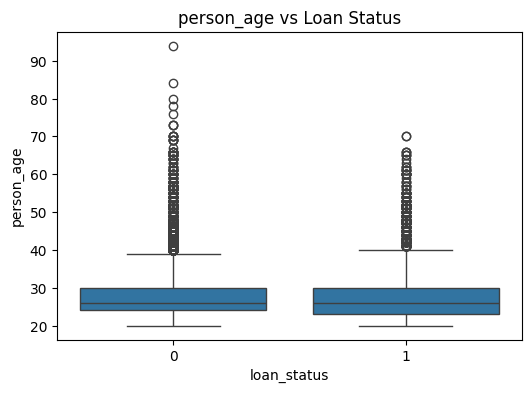

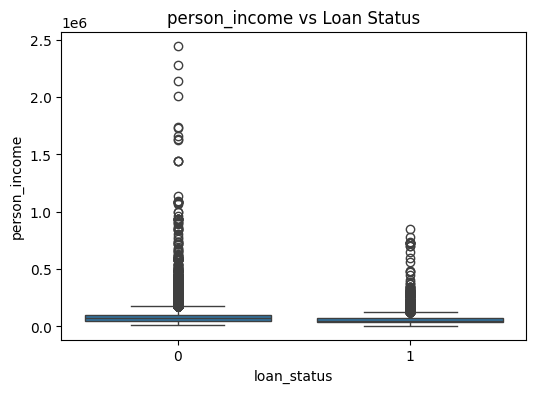

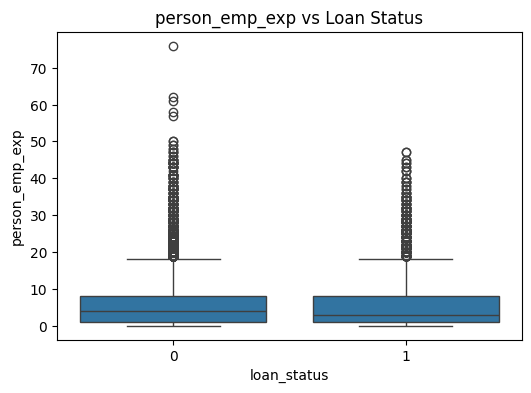

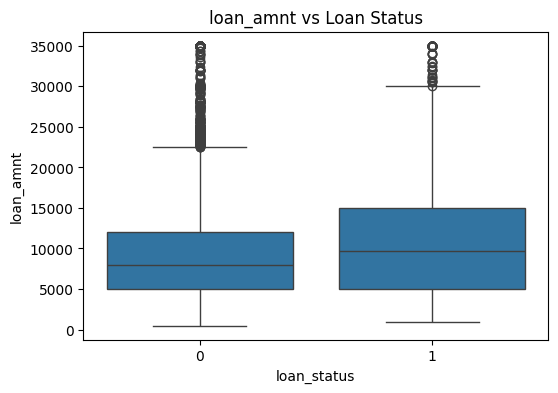

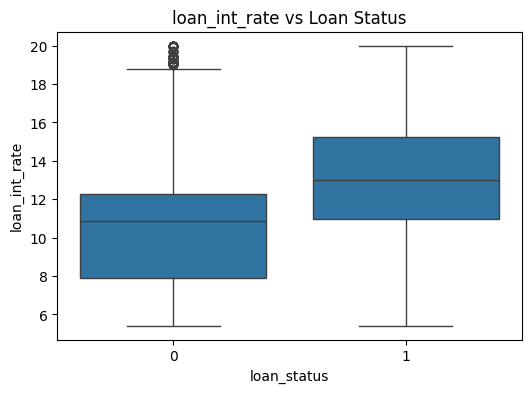

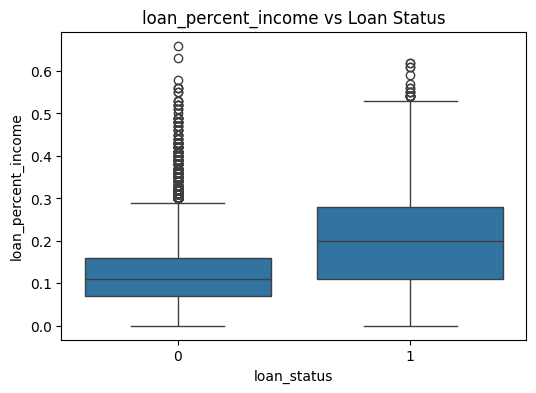

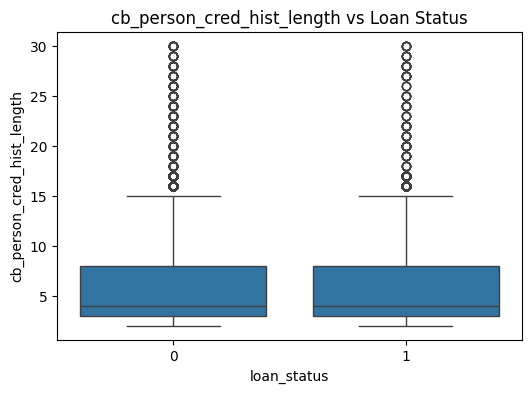

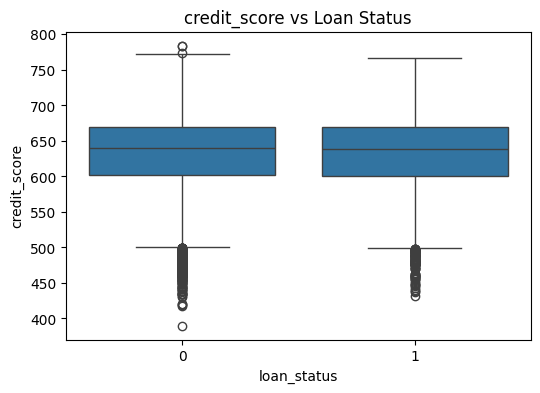

In [59]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns 
num_cols = num_cols.drop('loan_status')
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='loan_status', y=col, data=df)
    plt.title(f"{col} vs Loan Status")
    plt.show()

### 📈 Feature Distribution by Loan Status

KDE plots are used to compare the distribution of each numerical feature between **approved (1)** and **rejected (0)** loans.

They help us:
- Visualize the **shape of the distribution**
- See how much the two groups **overlap**
- Identify features that **separate the classes well**

Less overlap between the two curves indicates a stronger feature for predicting loan approval.

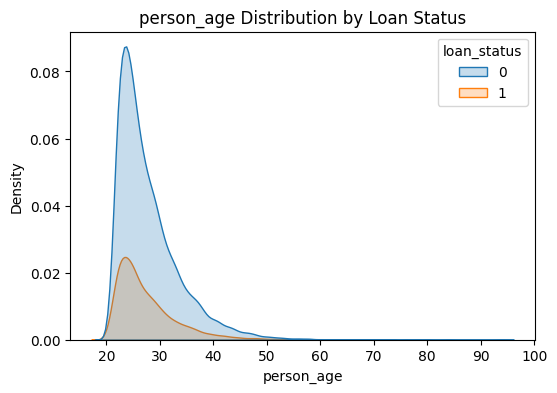

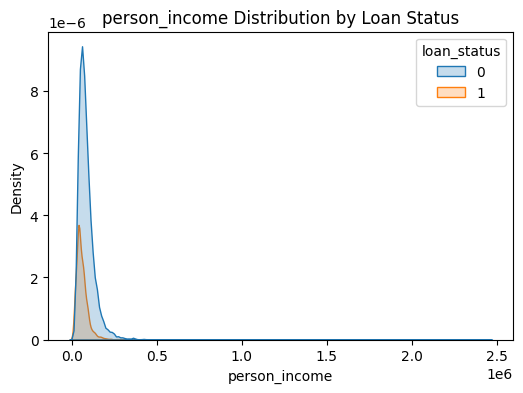

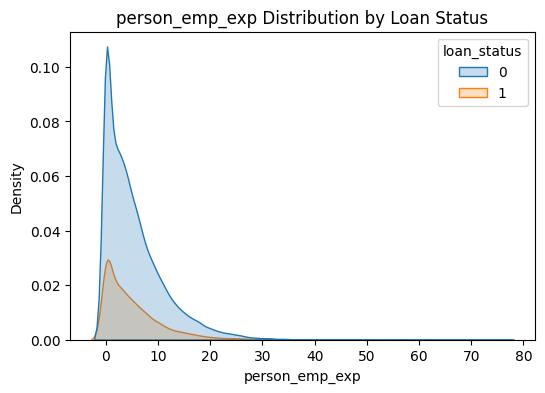

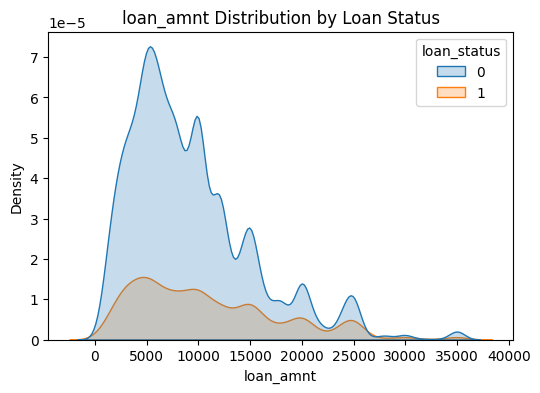

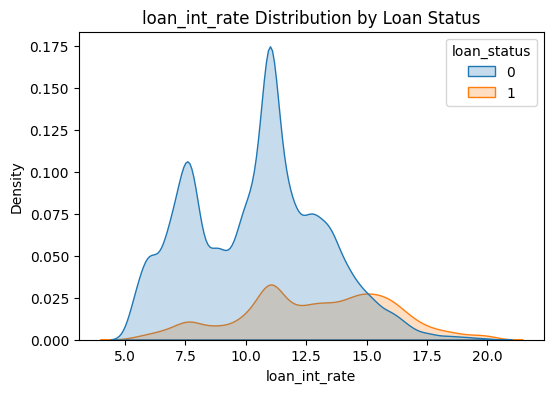

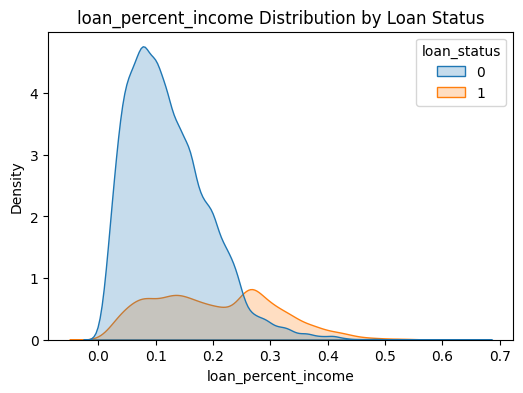

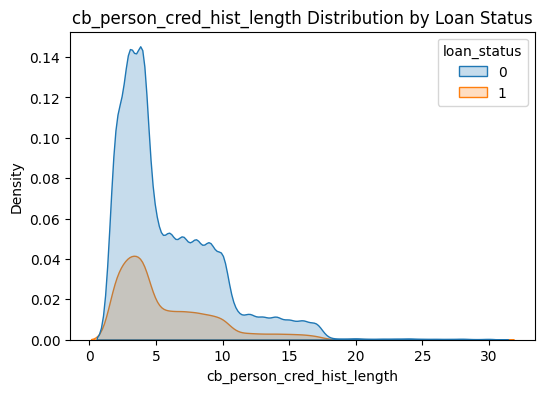

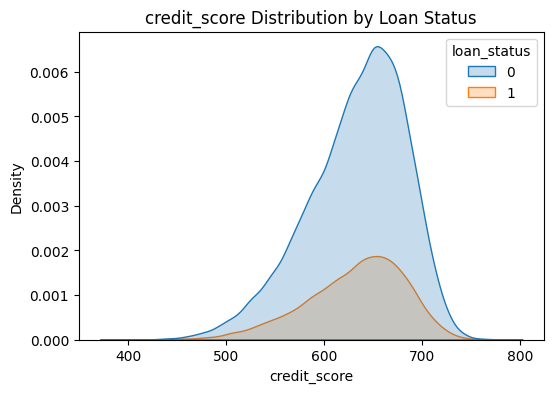

In [60]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=df, x=col, hue='loan_status', fill=True)
    plt.title(f"{col} Distribution by Loan Status")
    plt.show()

### 🔗 Correlation Analysis

We analyze the correlation between numerical features and the target variable (**loan_status**) to identify the most important predictors.

Only features with a correlation greater than **0.1** are selected to reduce noise and focus on the most relevant variables.

The heatmap helps visualize relationships between these important features and highlights how strongly they are associated with loan approval.

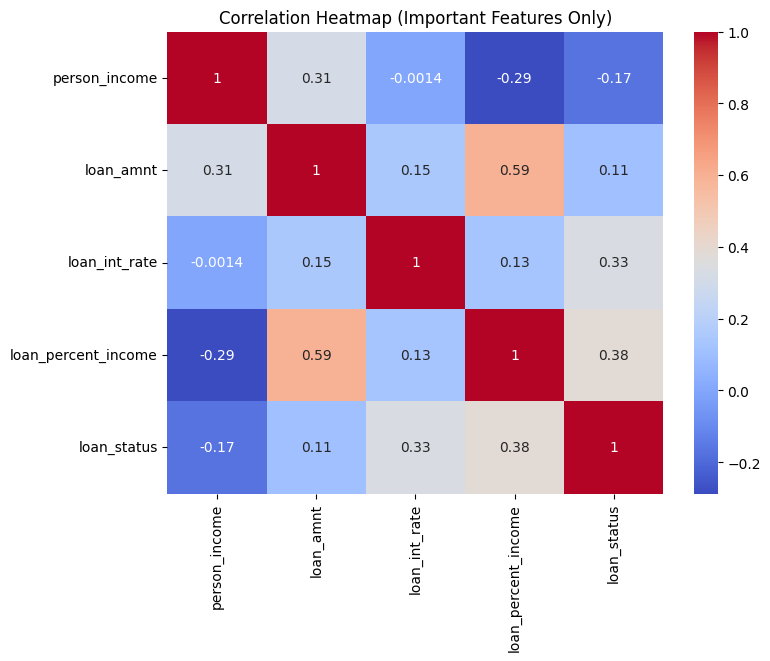

In [61]:
df_corr = df.select_dtypes('number').corr()

corr_with_target = df_corr['loan_status'].abs()

important_cols = corr_with_target[corr_with_target > 0.1].index

df_corr_filtered = df_corr.loc[important_cols, important_cols]

plt.figure(figsize=(8,6))
sns.heatmap(df_corr_filtered, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Important Features Only)")
plt.show()


In [50]:
df.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')

### 🔄 Preprocessing Categorical Features

Machine learning models require **numeric input**, so we need to convert all categorical and boolean features into a numeric format. This process includes:

1. **Mapping Ordinal Features:**  
   Features with a natural order (e.g., education level: High School < Bachelor < Master < Doctorate) are mapped to numeric values that preserve this order.  
   - Purpose: Models can understand the progression or ranking between categories.

2. **One-Hot Encoding Nominal Features:**  
   Features with no inherent order (e.g., home ownership: Rent, Mortgage, Own) are converted into separate binary columns for each category.  
   - Purpose: Models treat each category independently without implying any ranking.

3. **Converting Boolean Columns:**  
   Columns with True/False values are converted to 1/0.  
   - Purpose: Ensures all features are numeric and can be used in calculations by ML algorithms.

**Overall Use:**  
- Produces a **fully numeric dataset**, ready for all types of machine learning models.  
- Prevents models from making **incorrect assumptions about category order**.  
- Improves **model interpretability and performance** by correctly encoding categorical information.

In [62]:
df['person_education'] = df['person_education'] = df['person_education'].map({'High School': 1,
    'Associate': 2,
    'Bachelor': 3,
    'Master': 4,
    'Doctorate': 5})
df['previous_loan_defaults_on_file'] = df['previous_loan_defaults_on_file'].map({'No': 0, 'Yes': 1})


In [ ]:
df = pd.get_dummies(df, columns=['person_home_ownership', 'loan_intent', 'person_gender'], drop_first=True)
bool_cols = df.select_dtypes('bool').columns
df[bool_cols] = df[bool_cols].astype(int)


### 📊 Splitting the Data into Training and Testing Sets

Before training a machine learning model, it is important to **separate the dataset into features and target**, and then split it into **training and testing sets**:

1. **Features (X):**  
   All columns **except the target** (`loan_status`) that will be used to predict the outcome.

2. **Target (y):**  
   The column we want the model to predict (`loan_status`).

3. **Train-Test Split:**  
   - The dataset is divided into **training (80%)** and **testing (20%)** sets.  
   - Purpose of training set: to **teach the model** patterns in the data.  
   - Purpose of testing set: to **evaluate model performance** on unseen data.  

**Why this is important:**  
- Ensures that model evaluation is **unbiased** and reflects real-world performance.  
- Prevents **overfitting**, where the model memorizes the data instead of learning general patterns.

In [65]:
X = df.drop(columns='loan_status' , axis= 1)
y = df['loan_status'].to_frame()

In [66]:
from sklearn.model_selection import train_test_split
X_train , X_test ,y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42)

### 🤖 Logistic Regression Model

The first model we use is **Logistic Regression**, which is suitable for **binary classification problems**, such as predicting loan approval (approved vs rejected).

**Key points:**
- Predicts the **probability** of each class (loan approved or rejected).  
- Learns **weights for each feature** to determine how strongly they influence the outcome.  
- Simple, interpretable, and often a good **baseline model** for classification tasks.

**Purpose in our workflow:**
- Provides a **first benchmark** for model performance.  
- Helps identify **important features** and patterns in the data.  
- Can be compared later with more complex models like Random Forest or XGBoost.

In [71]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train , y_train)
from sklearn.metrics import confusion_matrix , classification_report
y_pred = lr.predict(X_test)
print(classification_report  (y_test, y_pred))
print(confusion_matrix (y_test, y_pred))

c:\Python312\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


              precision    recall  f1-score   support

           0       0.87      0.94      0.91      7002
           1       0.72      0.52      0.60      1997

    accuracy                           0.85      8999
   macro avg       0.80      0.73      0.75      8999
weighted avg       0.84      0.85      0.84      8999

[[6609  393]
 [ 966 1031]]


c:\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


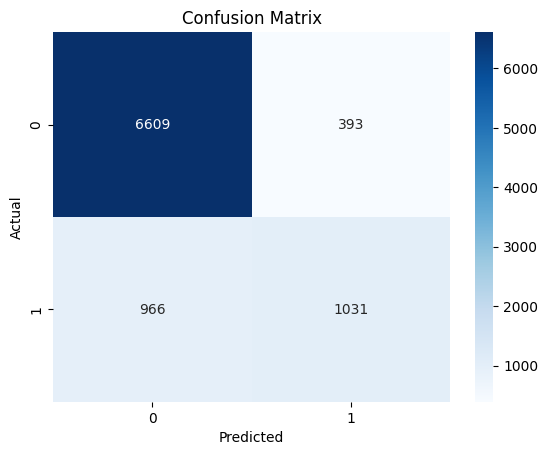

In [72]:
cm=confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### 📈 Logistic Regression Results

After training the Logistic Regression model:

- **Training Accuracy:** 0.84  
- **Testing Accuracy:** 0.85  

**Interpretation:**
- The model performs consistently on both the training and testing sets, indicating **good generalization**.  
- No significant overfitting is observed since train and test accuracies are similar.  
- Logistic Regression provides a **strong baseline** for predicting loan approval, which can be improved with more complex models.

In [ ]:
train_accuracy = lr.score(X_train, y_train)
test_accuracy = lr.score(X_test, y_test)
print(f"Train Accuracy: {train_accuracy}")
print(f"Test Accuracy: {test_accuracy}")

Train Accuracy: 0.8443907317886314
Test Accuracy: 0.8489832203578175


### 🌟 XGBoost Classifier

The XGBoost model is a **powerful gradient boosting algorithm** used for classification tasks. It often outperforms simpler models like Logistic Regression, especially on **imbalanced or complex datasets**.

**Key points about this setup:**
- **n_estimators=300, learning_rate=0.05, max_depth=5:** Controls the number of trees, learning speed, and tree complexity.  
- **subsample=0.8, colsample_bytree=0.8:** Helps reduce overfitting by sampling rows and features.  
- **scale_pos_weight:** Adjusts for class imbalance between approved and rejected loans.  
- **random_state=42:** Ensures reproducibility.

**Purpose in our workflow:**
- Provides a **more sophisticated model** capable of capturing non-linear patterns.  
- Handles **feature interactions** automatically.  
- Allows comparison with Logistic Regression to see if complex models improve prediction.

**Performance metrics:**
- **Train Accuracy:** Measures how well the model fits the training data.  
- **Test Accuracy:** Measures performance on unseen data to check generalization.

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    scale_pos_weight=(len(y_train[y_train==0]) / len(y_train[y_train==1]))
)
xgb.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Optional[float]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[str], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load

### 📊 XGBoost Classifier Results

After training the XGBoost model:

- **Training Accuracy:** 0.94  
- **Testing Accuracy:** 0.93  

**Interpretation:**
- The model performs **very well** on both training and testing sets.  
- Small difference between train and test accuracy indicates **minimal overfitting**.  
- XGBoost captures **complex patterns and feature interactions**, improving performance over the baseline Logistic Regression model.  
- This demonstrates that gradient boosting is highly effective for predicting loan approval in this dataset.

In [75]:
train_accuracy = xgb.score(X_train, y_train)
test_accuracy = xgb.score(X_test, y_test)
print(f"Train Accuracy: {train_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")

Train Accuracy: 0.94
Test Accuracy: 0.93
